In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize, theory, cluster_utils

%load_ext autoreload
%autoreload 2

local_path = '/Users/haozheshan/Dropbox/codes/gp_continual_learning/cluster_results'

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

organizer =\
    cluster_utils.ClusterResultOrganizer(local_path, batch_name='SGD_2x1000_fashion_3L_permute1.0_TEST')
organizer.load_all()
organize_key = 'l2'
all_test_acc = organizer.organize_results('test acc', organize_key)
all_train_acc = organizer.organize_results('train acc', organize_key)
all_test_var = organizer.organize_results('test var', organize_key)
all_train_var = organizer.organize_results('train var', organize_key)
all_test_loss = organizer.organize_results('test loss', organize_key)
all_train_loss = organizer.organize_results('train loss', organize_key)


title_text = f'{organizer.args.dataset}, P={organizer.args.P},' +\
          f'\n {organizer.args.n_tasks} tasks,' \
          f' permutation:{bool(organizer.args.permutation)},' \
          f'Depth:{organizer.args.depth}, N:{organizer.args.N}'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
128 data objects loaded.
Organizer: data with key test var were not found
Organizer: data with key train var were not found


Text(0, 0.5, 'test loss')

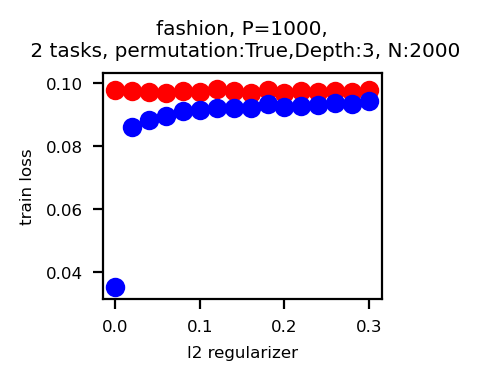

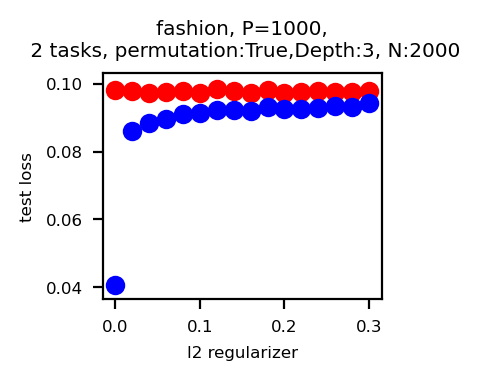

In [33]:
def plot_loss_over_lambda(all_xxx_loss):

    plt.figure()
    for key in all_test_acc.keys():
        plt.errorbar(float(key), all_xxx_loss[key].mean(0)[0, 1],
                     all_xxx_loss[key].std(0)[0, 1], color='r', marker='o')
        plt.errorbar(float(key), all_xxx_loss[key].mean(0)[1, 1],
                     all_xxx_loss[key].std(0)[1, 1], color='b', marker='o')
    plt.xlabel('l2 regularizer')
    plt.title(title_text)


plot_loss_over_lambda(all_train_loss); plt.ylabel('train loss')

plot_loss_over_lambda(all_test_loss); plt.ylabel('test loss')

Text(0.5, 1.0, 'train loss \nfashion, P=1000,\n 2 tasks, permutation:True,Depth:3, N:2000')

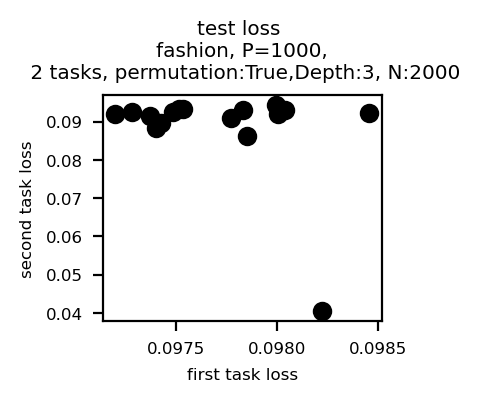

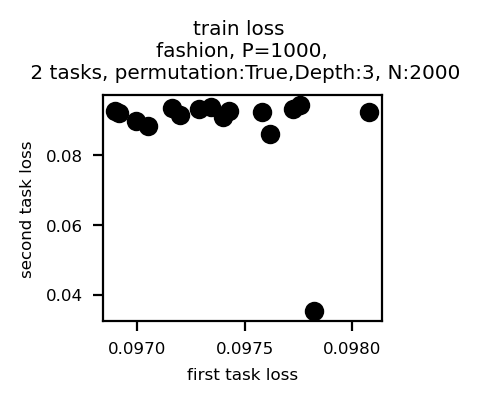

In [34]:
def plot_loss_on_2d(all_xxx_loss):

    plt.figure()
    for key in all_test_acc.keys():
        plt.scatter(all_xxx_loss[key].mean(0)[0, 1], all_xxx_loss[key].mean(0)[1, 1],
                     color='k', marker='o')
    plt.xlabel('first task loss')
    plt.ylabel('second task loss')

plot_loss_on_2d(all_test_loss)
plt.title('test loss \n' + title_text)

plot_loss_on_2d(all_train_loss)
plt.title('train loss \n' + title_text)
